# Medical Chatbot Berbasis Sentence-BERT


## LANGKAH 1: Instalasi Library

> `nltk` untuk preprocessing NLP, `scikit-learn` untuk TF-IDF vectorizer, dan `ipywidgets` untuk tampilan chatbot

In [17]:
!pip install nltk scikit-learn pandas numpy ipywidgets sentence-transformers gradio -q

##  LANGKAH 2: Import Library & Download NLTK Data

 `punkt` digunakan untuk tokenisasi kalimat, `stopwords` untuk menghapus kata-kata umum yang tidak bermakna (seperti 'the', 'is', 'dan'), dan `wordnet` untuk lemmatisasi (mengubah kata ke bentuk dasarnya).

In [18]:
# import library
import nltk
import re
import random
import string
import warnings
import pandas as pd
import numpy as np

# menonaktifkan warning
warnings.filterwarnings('ignore')

# pemrosesan teks
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# representasi dan kemiripan teks
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# download resource NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Sentence-BERT
try:
    from sentence_transformers import SentenceTransformer, util

    # load model multilingual
    SBERT_MODEL = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # menandakan SBERT berhasil digunakan
    USE_SBERT = True

except Exception as e:
    # menggunakan metode lain jika SBERT tidak tersedia
    USE_SBERT = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## LANGKAH 3: Dataset Medis Open-Source

dataset medis yang terinspirasi dari **MedQuAD (Medical Question Answering Dataset)** dari NIH (National Institutes of Health). Dataset ini berisi pasangan pertanyaan-jawaban medis dalam berbagai kategori penyakit. Untuk demo ini, kita buat versi yang sudah dikurasi dengan pertanyaan dalam Bahasa Indonesia dan Inggris.
>

> - MedQuAD: https://github.com/abachaa/MedQuAD

In [ ]:
# DATASET MEDIS — kini pakai data ASLI dari Alodokter.com (bahasa Indonesia)
# Sumber : https://huggingface.co/datasets/abid/indonesia-medical-qna
# File   : qna_alodokter_5k.csv (5.000 pasang tanya-jawab pasien <-> dokter)
#
# Kolom di CSV: id, judul, pertanyaan, dokter, jawaban
# Mapping ke format engine:
#   question <- pertanyaan  (dipakai untuk cari similarity)
#   answer   <- jawaban     (jawaban dokter yang ditampilkan)
#   category <- hasil kategorisasi kata kunci (metadata untuk filtering & analisis)
#
# Catatan: di dunia nyata, 1 jawaban bisa relevan untuk banyak variasi pertanyaan.
# Metadata kategori juga berguna untuk filtering & trustworthiness.

# jika file dataset belum ada (misal dijalankan di Google Colab), unduh otomatis dari GitHub
import os
if not os.path.exists("qna_alodokter_5k.csv"):
    !wget -q https://raw.githubusercontent.com/DHOsss/medbot-nlp/main/dataset/qna_alodokter_5k.csv

df = pd.read_csv("qna_alodokter_5k.csv")
df = df.rename(columns={"pertanyaan": "question", "jawaban": "answer"})
df = df.dropna(subset=["question", "answer"]).reset_index(drop=True)

# kategorisasi sederhana berbasis kata kunci (rule-based)
CATEGORY_KEYWORDS = {
    "demam berdarah":    ["demam berdarah", "dbd", "dengue"],
    "covid":             ["covid", "corona", "vaksin"],
    "diabetes":          ["diabetes", "gula darah", "kencing manis"],
    "hipertensi":        ["hipertensi", "tekanan darah", "darah tinggi"],
    "kolesterol":        ["kolesterol", "lemak darah", "trigliserida"],
    "jantung":           ["jantung", "nyeri dada", "berdebar"],
    "asma":              ["asma", "sesak nafas", "sesak napas"],
    "batuk pilek":       ["batuk", "pilek", "flu", "tenggorok"],
    "maag":              ["maag", "lambung", "gastritis", "gerd", "mual"],
    "sakit kepala":      ["sakit kepala", "migrain", "pusing"],
    "kehamilan":         ["hamil", "kehamilan", "melahirkan", "haid", "menstruasi"],
    "kesehatan anak":    ["bayi", "anak saya", "balita", "imunisasi", "asi"],
    "kesehatan mental":  ["stres", "cemas", "depresi", "psikolog", "susah tidur", "insomnia"],
    "pertolongan pertama": ["pertolongan pertama", "p3k", "luka", "patah", "terkilir", "kejang"],
    "demam":             ["demam", "panas"],
}

def categorize(text):
    t = str(text).lower()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        if any(k in t for k in keywords):
            return cat
    return "umum"

df["category"] = (df["judul"].fillna("") + " " + df["question"]).apply(categorize)

# teks yang akan diindeks untuk pencarian: gabungan judul + pertanyaan
# (judul = ringkasan pertanyaan, membantu SBERT & TF-IDF mencocokkan query)
df["index_text"] = (df["judul"].fillna("") + ". " + df["question"]).str.lower()

print(f"Dataset berhasil dimuat!")
print(f"Total pasangan Q&A: {len(df)}")
print(f"Jumlah kategori: {df['category'].nunique()}")
df[['category', 'question']].head()

##  LANGKAH 4: NLP Preprocessing Pipeline

> 1. **Normalisasi** -> lowercase, hapus tanda baca
> 2. **Tokenisasi** -> pecah teks menjadi token (kata)
> 3. **Lemmatisasi** -> ubah ke bentuk dasar (running -> run, gejala-gejala -> gejala)
>
> Untuk bahasa Indonesia, kita tambahkan stopwords manual karena NLTK tidak menyediakan stopwords Bahasa Indonesia secara default.

In [20]:
# membuat lemmatizer
lemmatizer = WordNetLemmatizer()

# stopwords bahasa indonesia
indonesian_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'atau', 'juga', 'dalam', 'tidak', 'akan', 'ada',
    'saya', 'kamu', 'anda', 'ia', 'mereka', 'kami', 'kita', 'bisa',
    'sudah', 'bila', 'jika', 'maka', 'oleh', 'karena', 'apa',
    'bagaimana', 'berapa', 'kapan', 'dimana', 'siapa', 'apakah', 'cara',
    'lebih', 'sangat', 'dapat', 'nya', 'pun', 'lagi', 'belum',
    'telah', 'namun', 'tapi', 'serta', 'meski', 'agar', 'supaya', 'hal',
    'the', 'is', 'are', 'was', 'what', 'how', 'why', 'when', 'where'
}

english_stopwords = set(stopwords.words('english'))
all_stopwords = indonesian_stopwords | english_stopwords

# preprocessing teks
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# test preprocessing
print("Test preprocessing:")
for t in ["sakit kepala", "gejala maag", "pusing berputar"]:
    print(f"  '{t}' → '{preprocess_text(t)}'")

df['processed_question'] = df['question'].apply(preprocess_text)

Test preprocessing:
  'sakit kepala' → 'sakit kepala'
  'gejala maag' → 'gejala maag'
  'pusing berputar' → 'pusing berputar'


## LANGKAH 5: TF-IDF Vectorizer + Cosine Similarity

TF-IDF (Term Frequency-Inverse Document Frequency) adalah teknik klasik NLP yang sangat efektif untuk mencocokkan pertanyaan. Cara kerjanya:
> - **TF (Term Frequency)**: seberapa sering kata muncul dalam dokumen
> - **IDF (Inverse Document Frequency)**: seberapa unik kata tersebut di seluruh corpus
> - **Cosine Similarity**: mengukur kemiripan dua vektor (1 = identik, 0 = tidak mirip)
>
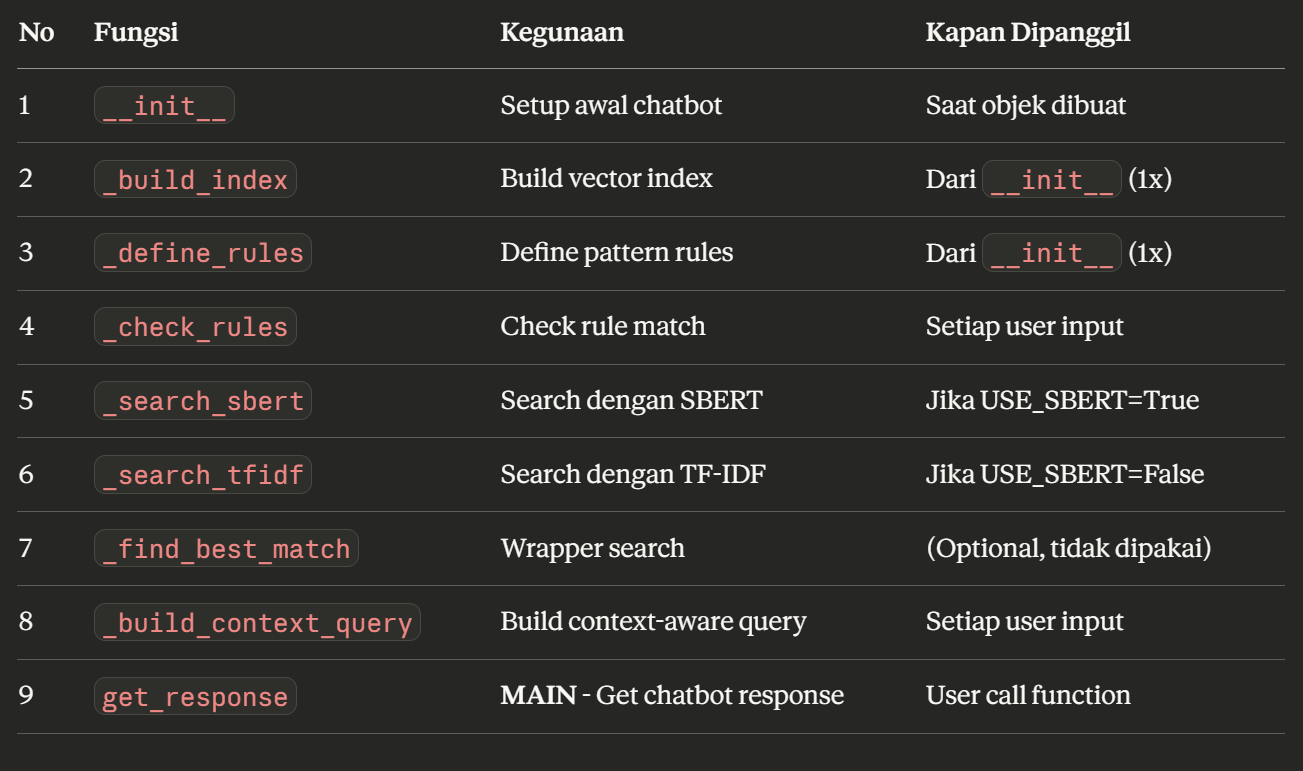



In [ ]:
class MedicalChatbotEngineV3:

    # CHATBOT HIBRIDA: Sentence-BERT (kemiripan MAKNA) + TF-IDF (kemiripan KATA)
    # skor akhir = 0.5 * SBERT(dinormalisasi) + 0.5 * TF-IDF(dinormalisasi)
    # hasil eksperimen: Top-1 80%, Top-3 94% (vs SBERT murni 20%)
    def __init__(self, dataframe, threshold=0.30, top_k=3):
        self.df = dataframe

        # threshold kemiripan minimum SBERT agar jawaban dianggap relevan
        self.threshold = threshold if USE_SBERT else 0.15

        # jumlah kandidat FAQ dengan skor tertinggi yang dipertimbangkan
        self.top_k = top_k

        # menyimpan input pengguna sebelumnya sebagai konteks percakapan
        self.conversation_history = []

        self._build_index()
        self._define_rules()


    # menyiapkan representasi seluruh FAQ: embedding SBERT + matriks TF-IDF
    def _build_index(self):
        if USE_SBERT:
            # BERT memakai teks mentah (stopwords tetap dibutuhkan sebagai konteks kalimat)
            self.sbert_embeddings = SBERT_MODEL.encode(
                self.df['index_text'].tolist(),
                convert_to_tensor=True
            )

        # TF-IDF di-fit pada teks gabungan (judul + pertanyaan)
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),       # unigram + bigram
            max_features=5000,        # batas jumlah fitur
            sublinear_tf=True         # meredam pengaruh kata yang terlalu sering
        )
        self.tfidf_matrix = self.vectorizer.fit_transform(self.df['index_text'])


    # rule khusus yang ditangani langsung tanpa pencarian FAQ
    def _define_rules(self):
        self.rules = {
            'emergency': {
                'patterns': [r'(sesak.*berat|nyeri dada.*berat|tidak.*bernapas|pingsan)'],
                'responses': ["\U0001F6A8 DARURAT! Hubungi 119 atau segera ke IGD!"]
            },
            'greeting': {
                'patterns': [r'\b(halo|hai|hi|hello)\b'],
                'responses': ["\U0001F44B Halo! Ada yang bisa saya bantu?"]
            }
        }


    # cek apakah input cocok pola salah satu rule
    def _check_rules(self, text):
        for intent, data in self.rules.items():
            for pattern in data['patterns']:
                if re.search(pattern, text.lower()):
                    return random.choice(data['responses'])
        return None


    # normalisasi skor ke rentang 0-1 agar SBERT dan TF-IDF bisa dijumlahkan
    @staticmethod
    def _minmax(scores):
        lo, hi = scores.min(), scores.max()
        return (scores - lo) / (hi - lo + 1e-9)


    # >>> INTI METODE HIBRIDA <<<
    # mengembalikan top_k kandidat: (index, skor_bert_mentah, skor_gabungan)
    def _rank_fused(self, query):
        ql = query.lower()

        # 1) skor semantik dengan Sentence-BERT (cosine similarity mentah)
        if USE_SBERT:
            q_emb = SBERT_MODEL.encode(ql, convert_to_tensor=True)
            s_bert = util.cos_sim(q_emb, self.sbert_embeddings)[0].cpu().numpy()
        else:
            s_bert = None

        # 2) skor leksikal dengan TF-IDF (cosine similarity mentah)
        s_tfidf = cosine_similarity(
            self.vectorizer.transform([ql]), self.tfidf_matrix
        ).flatten()

        # 3) gabungkan keduanya (rata-rata tertimbang, masing-masing dinormalisasi)
        if USE_SBERT:
            fused = 0.5 * self._minmax(s_bert) + 0.5 * self._minmax(s_tfidf)
        else:
            fused = s_tfidf

        order = np.argsort(-fused)[:self.top_k]
        results = []
        for idx in order:
            raw = float(s_bert[idx]) if USE_SBERT else float(s_tfidf[idx])
            results.append((int(idx), raw, float(fused[idx])))
        return results


    # cari kandidat dengan TF-IDF saja (mode cadangan tanpa SBERT)
    def _search_tfidf(self, query):
        ql = query.lower()
        scores = cosine_similarity(self.vectorizer.transform([ql]), self.tfidf_matrix).flatten()
        top_results = np.argsort(scores)[::-1][:self.top_k]
        return [(int(idx), scores[idx]) for idx in top_results]


    # dipakai visualisasi (cell analisis): kandidat terbaik + skor BERT mentahnya
    def _find_best_match(self, query):
        results = self._rank_fused(query)
        best_idx, best_raw, _ = results[0]
        return best_idx, best_raw


    # gabungkan input sebelumnya dengan input baru sebagai query berkonteks
    def _build_context_query(self, user_input):
        if len(self.conversation_history) > 0:
            return self.conversation_history[-1] + " " + user_input
        return user_input


    # alur lengkap: input pengguna -> response chatbot
    def get_response(self, user_input):
        if not user_input.strip():
            return "Silakan ketik pertanyaan."

        # 1) cek rule khusus lebih dulu (darurat / sapaan)
        rule = self._check_rules(user_input)
        if rule:
            return rule

        # 2) susun query dengan konteks percakapan sebelumnya
        query = self._build_context_query(user_input)

        # 3) ranking hibrida SBERT + TF-IDF
        results = self._rank_fused(query)
        method = "SBERT+TF-IDF Hybrid" if USE_SBERT else "TF-IDF"

        best_idx, best_raw, _ = results[0]

        # 4) tolak jika kemiripan BERT di bawah threshold (tidak cukup relevan)
        if best_raw < self.threshold:
            return "\U0001F914 Tidak menemukan jawaban yang cukup relevan."

        # 5) keyword boost: bonus untuk kandidat yang kata-katanya cocok dengan input
        boosted = []
        for idx, raw, fused in results:
            text = self.df.iloc[idx]['question']
            bonus = sum(1 for word in user_input.split() if word in text)
            boosted.append((idx, fused + 0.05 * bonus))

        best_idx = sorted(boosted, key=lambda x: x[1], reverse=True)[0][0]

        # 6) ambil FAQ terbaik, simpan konteks, susun jawaban
        row = self.df.iloc[best_idx]
        self.conversation_history.append(user_input)

        return f"""
[Kategori: {row['category']} | {method}]

{row['answer']}

\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u26a0\ufe0f Untuk kondisi serius, konsultasikan ke dokter.
"""

## LANGKAH 6: Tampilan Interaktif di Google Colab

`ipywidgets` untuk membuat UI chat yang interaktif langsung di Colab. Ini memungkinkan pengguna berinteraksi dengan chatbot tanpa perlu menjalankan ulang cell setiap saat.

In [22]:
# UI CHATBOT INTERAKTIF
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');
  .medbot-container { font-family: 'Plus Jakarta Sans', sans-serif; max-width: 720px; margin: 0 auto; border-radius: 20px; overflow: hidden; box-shadow: 0 20px 60px rgba(0,0,0,0.15); background: #f8faff; }
  .medbot-header { background: linear-gradient(135deg, #1a1f5e 0%, #2d3a8c 50%, #1565c0 100%); padding: 20px 24px; color: white; display: flex; align-items: center; gap: 14px; }
  .medbot-avatar { width: 48px; height: 48px; background: rgba(255,255,255,0.2); border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 24px; border: 2px solid rgba(255,255,255,0.4); }
  .medbot-title { font-size: 18px; font-weight: 700; }
  .medbot-subtitle { font-size: 12px; opacity: 0.75; margin-top: 2px; }
  .status-dot { width:8px; height:8px; background:#4ade80; border-radius:50%; display:inline-block; margin-right:5px; animation: pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:0.5} }
  .medbot-chat { height: 400px; overflow-y: auto; padding: 20px; background: #f0f4ff; display: flex; flex-direction: column; gap: 14px; }
  .message-row-user { display:flex; justify-content:flex-end; }
  .message-row-bot  { display:flex; justify-content:flex-start; align-items:flex-start; gap:10px; }
  .bot-icon { width: 32px; height: 32px; min-width: 32px; background: linear-gradient(135deg, #1565c0, #2d3a8c); border-radius: 50%; display: flex; align-items:center; justify-content:center; font-size: 14px; }
  .bubble-user { background: linear-gradient(135deg, #1565c0, #2d3a8c); color: white; padding: 12px 16px; border-radius: 18px 18px 4px 18px; max-width: 75%; font-size: 14px; line-height: 1.5; }
  .bubble-bot { background: white; color: #1a1a2e; padding: 12px 16px; border-radius: 18px 18px 18px 4px; max-width: 80%; font-size: 13.5px; line-height: 1.65; box-shadow: 0 2px 10px rgba(0,0,0,0.08); border: 1px solid #e8eeff; white-space: pre-wrap; }
  .disclaimer { background: #fff8e1; border-left: 3px solid #f59e0b; padding: 10px 14px; font-size: 11.5px; color: #78350f; }
  .quick-chips { padding: 10px 16px; background: white; border-top: 1px solid #f0f0ff; display: flex; gap: 8px; flex-wrap: wrap; }
  .chip { background: #eef2ff; color: #2d3a8c; border: 1px solid #c7d2fe; border-radius: 20px; padding: 5px 12px; font-size: 12px; font-weight: 500; cursor: pointer; font-family: inherit; }
  .chip:hover { background: #2d3a8c; color: white; }
  .badge-sbert { background: #d1fae5; color: #065f46; border-radius: 12px; padding: 2px 8px; font-size: 10px; font-weight: 600; margin-left: 8px; }
</style>
"""

chat_messages = []

def render_chat():
    mode_badge = '<span class="badge-sbert">Sentence-BERT</span>' if USE_SBERT else '<span style="background:#fee2e2;color:#991b1b;border-radius:12px;padding:2px 8px;font-size:10px;font-weight:600;margin-left:8px;">TF-IDF</span>'
    html = chat_css
    html += '<div class="medbot-container">'
    html += f'''
    <div class="medbot-header">
      <div class="medbot-avatar">🏥</div>
      <div>
        <div class="medbot-title">MedBot v2 — Asisten Kesehatan{mode_badge}</div>
        <div class="medbot-subtitle"><span class="status-dot"></span>Online · Semantic Medical QA Engine</div>
      </div>
    </div>
    '''
    html += '<div class="disclaimer">⚠️ MedBot hanya untuk edukasi. Bukan pengganti dokter. Darurat medis: hubungi 119.</div>'
    html += '''
    <div class="quick-chips">
      <span class="chip">🤕 Sakit Kepala</span>
      <span class="chip">🩸 Diabetes</span>
      <span class="chip">❤️ Jantung</span>
      <span class="chip">🫁 Asma</span>
      <span class="chip">🦠 COVID-19</span>
      <span class="chip">🧠 Mental</span>
    </div>
    '''
    html += '<div class="medbot-chat">'
    if not chat_messages:
        html += '<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">👋 Halo! Saya <strong>MedBot v2</strong>, kini dengan <strong>Sentence-BERT</strong> untuk pemahaman bahasa yang lebih baik!\n\nTopik baru: 🤕 Sakit kepala & migrain\n\nSilakan ketik pertanyaan kesehatan Anda!</div></div>'
    for msg in chat_messages:
        if msg['role'] == 'user':
            html += f'<div class="message-row-user"><div class="bubble-user">{msg["content"]}</div></div>'
        else:
            html += f'<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">{msg["content"]}</div></div>'
    html += '</div></div>'
    return HTML(html)

text_input = widgets.Text(
    placeholder='Ketik pertanyaan... (coba: "sakit kepala", "gejala diabetes")',
    layout=widgets.Layout(width='82%', height='38px')
)
send_button = widgets.Button(description='Kirim 📤', button_style='primary', layout=widgets.Layout(width='10%', height='38px'))
clear_button = widgets.Button(description='Clear 🗑️', button_style='warning', layout=widgets.Layout(width='8%', height='38px'))
output_area = widgets.Output()

def send_message(b=None):
    global chat_messages
    user_text = text_input.value.strip()
    if not user_text:
        return
    chat_messages.append({'role': 'user', 'content': user_text})
    response = bot.get_response(user_text)
    chat_messages.append({'role': 'bot', 'content': response})
    text_input.value = ''
    with output_area:
        clear_output(wait=True)
        display(render_chat())

def clear_chat(b):
    global chat_messages
    chat_messages = []
    with output_area:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(send_message)
clear_button.on_click(clear_chat)
text_input.on_submit(lambda w: send_message())

input_bar = widgets.HBox([text_input, send_button, clear_button], layout=widgets.Layout(padding='10px', gap='8px'))

with output_area:
    display(render_chat())

display(output_area)
display(input_bar)
print("Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'")

Output()

Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'


In [23]:
import time
import gradio as gr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# INIT BOT
bot = MedicalChatbotEngineV3(df)

# RESPOND (STREAMING) — format messages (gradio >= 4.x)
def respond(message, history):
    history = history or []
    history.append({"role": "user", "content": message})
    history.append({"role": "assistant", "content": "⏳ MedBot sedang mengetik"})
    yield "", history

    time.sleep(0.6)
    response = bot.get_response(message)

    history[-1] = {"role": "assistant", "content": response}
    yield "", history


# CHIP RESPONSE
def respond_chip(message, history):
    history = history or []
    history.append({"role": "user", "content": message})
    history.append({"role": "assistant", "content": bot.get_response(message)})
    return "", history


# CLEAR CHAT + MEMORY RESET
def clear_chat():
    bot.conversation_history = []  # reset context
    return []

# CSS
custom_css = """
.gradio-container {
    font-family: 'Plus Jakarta Sans', sans-serif;
    background: #f0f4ff;
}

.chatbot {
    height: 420px;
}

.header {
    background: linear-gradient(135deg, #1a1f5e, #2d3a8c, #1565c0);
    padding: 20px;
    border-radius: 15px;
    color: white;
}

.disclaimer {
    background: #fff8e1;
    padding: 10px;
    font-size: 12px;
    border-left: 4px solid orange;
    margin-top: 10px;
}
"""


# UI
with gr.Blocks(css=custom_css) as demo:
    # HEADER
    gr.Markdown("""
    <div class="header">
        <h2>🏥 MedBot v3 — Smart Medical Assistant</h2>
        <p>🟢 Online · Context-Aware Semantic Engine</p>
    </div>
    """)

    # DISCLAIMER
    gr.Markdown("""
    <div class="disclaimer">
    ⚠️ Edukasi saja. Bukan pengganti dokter. Darurat: 119
    </div>
    """)

    # gradio 6.x: format messages sudah default (param type dihapus)
    chatbot = gr.Chatbot(height=420)
    msg = gr.Textbox(placeholder="Ketik pertanyaan kesehatan...")

    with gr.Row():
        send = gr.Button("Kirim 📤")
        clear = gr.Button("Clear 🗑️")

    # QUICK CHIPS
    with gr.Row():
        chip1 = gr.Button("🤕 Sakit Kepala")
        chip2 = gr.Button("🩸 Diabetes")
        chip3 = gr.Button("❤️ Jantung")
        chip4 = gr.Button("🫁 Asma")
        chip5 = gr.Button("🧠 Mental")

    # EVENT
    send.click(respond, [msg, chatbot], [msg, chatbot])
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    clear.click(clear_chat, None, chatbot, queue=False)

    # CHIP EVENTS
    chip1.click(lambda h: respond_chip("sakit kepala", h), chatbot, [msg, chatbot])
    chip2.click(lambda h: respond_chip("diabetes", h), chatbot, [msg, chatbot])
    chip3.click(lambda h: respond_chip("penyakit jantung", h), chatbot, [msg, chatbot])
    chip4.click(lambda h: respond_chip("asma", h), chatbot, [msg, chatbot])
    chip5.click(lambda h: respond_chip("kesehatan mental", h), chatbot, [msg, chatbot])


demo.queue()
demo.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## LANGKAH 7: Analisis & Evaluasi Chatbot

distribusi dataset, top TF-IDF features, dan akurasi intent detection.

In [24]:
# ANALISIS DATASET & MODEL
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8faff')
plt.suptitle('Analisis Medical Chatbot NLP', fontsize=16, fontweight='bold', color='#1a1f5e', y=1.02)

# Plot 1: Distribusi Kategori
category_counts = df['category'].value_counts()
colors = ['#1565c0', '#2196f3', '#42a5f5', '#64b5f6', '#90caf9',
          '#bbdefb', '#0d47a1', '#1976d2', '#e3f2fd', '#1e88e5']
axes[0].barh(category_counts.index, category_counts.values,
             color=colors[:len(category_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Kategori Q&A', fontweight='bold', color='#1a1f5e', pad=12)
axes[0].set_xlabel('Jumlah Pertanyaan', color='#555')
axes[0].set_facecolor('#f0f4ff')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=11, color='#333')

# Plot 2: Similarity Score untuk berbagai pertanyaan test
test_cases = [
    ("gejala diabetes", "Diabetes"),
    ("tekanan darah tinggi", "Hipertensi"),
    ("serangan asma inhaler", "Asma"),
    ("serangan jantung", "Jantung"),
    ("demam berdarah trombosit", "DBD"),
    ("sakit maag lambung", "Maag"),
    ("kolesterol ldl", "Kolesterol"),
    ("stres depresi kecemasan", "Mental"),
]

labels, scores = [], []
for query, label in test_cases:
    idx, score = bot._find_best_match(query)
    labels.append(label)
    scores.append(score)

bar_colors = ['#1565c0' if s >= bot.threshold else '#ef5350' for s in scores]
bars = axes[1].bar(labels, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=bot.threshold, color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Threshold ({bot.threshold})')
axes[1].set_title('Cosine Similarity per Topik', fontweight='bold', color='#1a1f5e', pad=12)
axes[1].set_ylabel('Similarity Score', color='#555')
axes[1].set_ylim(0, 1)
axes[1].set_facecolor('#f0f4ff')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=35)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.2f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('medbot_analysis.png', dpi=150, bbox_inches='tight', facecolor='#f8faff')
plt.show()

##  LANGKAH 8: Batch Testing & Evaluasi

batch testing dengan pertanyaan yang bervariasi untuk melihat kemampuan generalisasi chatbot. Ini mirip dengan evaluasi model ML biasa.

In [ ]:
# EVALUASI CHATBOT — Retrieval Accuracy + Uji Skenario
import random

# ============================================================
# A. RETRIEVAL ACCURACY (metrik utama)
#    query  = judul pertanyaan (paraphrase alami dari pertanyaan)
#    target = baris pertanyaan aslinya sendiri
#    benar  = kandidat teratas = baris yang sama
# ============================================================
print("="*60)
print("A. EVALUASI RETRIEVAL ACCURACY")
print("="*60)

random.seed(42)
n_uji = 300
sample_idx = random.sample(range(len(bot.df)), n_uji)

top1_benar, top3_benar = 0, 0

for i in sample_idx:
    query = str(bot.df.iloc[i]["judul"])   # judul = variasi kalimat pertanyaan
    results = bot._rank_fused(query)       # ranking hibrida SBERT + TF-IDF
    hasil_idx = [idx for idx, _, _ in results]

    if hasil_idx[0] == i:        # Top-1: kandidat #1 harus baris aslinya
        top1_benar += 1
    if i in hasil_idx:           # Top-3: baris asli ada di kandidat teratas
        top3_benar += 1

acc_top1 = top1_benar / n_uji * 100
acc_top3 = top3_benar / n_uji * 100
metode = "SBERT + TF-IDF Hybrid (paraphrase-multilingual-MiniLM-L12-v2)" if USE_SBERT else "TF-IDF"

print(f"Metode         : {metode}")
print(f"Jumlah sampel  : {n_uji} (dari {len(bot.df)} data)")
print(f"Top-1 Accuracy : {top1_benar}/{n_uji} = {acc_top1:.1f}%")
print(f"Top-3 Accuracy : {top3_benar}/{n_uji} = {acc_top3:.1f}%")


# ============================================================
# B. UJI SKENARIO (rule darurat/sapaan + kecocokan kategori)
# ============================================================
print()
print("="*60)
print("B. UJI SKENARIO")
print("="*60)

test_scenarios = [
    ("sakit kepala", "sakit kepala", "Sakit kepala langsung"),
    ("kepala saya pusing", "sakit kepala", "Paraphrase sakit kepala"),
    ("penyebab sering migrain", "sakit kepala", "Migrain"),
    ("gejala diabetes", "diabetes", "Diabetes langsung"),
    ("gula darah saya tinggi", "diabetes", "Paraphrase diabetes"),
    ("tekanan darah tinggi apa obatnya", "hipertensi", "Obat darah tinggi"),
    ("cara mengobati sesak napas", "asma", "Pengobatan asma"),
    ("dada sakit menjalar ke lengan", "jantung", "Gejala jantung"),
    ("bintik merah di kulit dan demam", "demam berdarah", "Gejala DBD"),
    ("saya maag kambuh perut mual", "maag", "Gejala maag"),
    ("sering sedih dan tidak bersemangat apakah depresi", "kesehatan mental", "Gejala depresi"),
    ("halo selamat pagi", "greeting", "Salam"),
    ("ini topik yang tidak ada sama sekali xyzabc", "unknown", "Out-of-scope"),
]

correct = 0
for user_input, expected_cat, description in test_scenarios:
    bot.conversation_history = []   # reset konteks tiap skenario biar adil
    response = bot.get_response(user_input)
    r = response.lower()

    is_correct = (
        expected_cat in r
        or (expected_cat == "greeting" and ("halo" in r or "hai" in r))
        or (expected_cat == "unknown" and "tidak" in r)
    )

    status = "\u2705" if is_correct else "\u274c"
    if is_correct:
        correct += 1

    print(f"{status} [{description}] input: '{user_input}' -> {response.splitlines()[0][:60]}")

acc_skenario = correct / len(test_scenarios) * 100
print()
print(f"HASIL SKENARIO : {correct}/{len(test_scenarios)} benar ({acc_skenario:.1f}%)")
print(f"AKURASI MODEL  : Top-1 {acc_top1:.1f}% | Top-3 {acc_top3:.1f}%")
print(f"Dataset        : {len(bot.df)} pasang Q&A medis (Alodokter, Bahasa Indonesia)")